In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

c:\Users\Preethika\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Preethika\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
np.random.seed(23) 

In [3]:
mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1
df

,feature1,feature2,feature3,target
0,0.666988,0.025813,-0.777619,1
1,0.948634,0.701672,-1.051082,1
2,-0.367548,-1.137460,-1.322148,1
3,1.772258,-0.347459,0.670140,1
4,0.322272,0.060343,-1.043450,1
5,-1.009942,0.441736,1.128877,1
6,-1.838068,-0.938769,-0.201841,1
7,1.045371,0.538162,0.812119,1
8,0.241106,-0.952510,-0.136267,1
9,1.267248,0.173634,-1.223255,1


In [4]:
mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0
df1

,feature1,feature2,feature3,target
0,1.250737,0.186384,1.703624,0
1,0.731858,0.517441,2.244610,0
2,1.676860,4.187503,-0.080565,0
3,1.010229,1.437830,2.327788,0
4,0.748855,2.593111,1.170818,0
5,0.290746,0.866975,0.982643,0
6,0.898907,0.435960,0.820964,0
7,2.011059,1.920996,2.933090,0
8,0.204637,-0.011535,3.150780,0
9,1.425140,1.441152,0.182561,0


In [5]:
#combine both to create a 3D data
df = pd.concat([df, df1], ignore_index=True)
df.sample(40)

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1
29,1.425140,1.441152,0.182561,0
31,2.224431,0.230401,1.192120,0
4,0.322272,0.060343,-1.043450,1
32,-0.723253,1.461259,-0.085367,0
33,2.823378,-0.332863,2.637391,0


In [8]:
df['target'] = df['target'].astype(str)

# Pass the dataframe once, then use string column names
fig = px.scatter_3d(
    df, 
    x='feature1', 
    y='feature2', 
    z='feature3', 
    color='target'
)
fig.show()

In [ ]:
# Step 1 - Apply standard scaling-mean centring
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df.iloc[:,0:3]=scaler.fit_transform(df.iloc[:,0:3])

In [12]:
# Step 2 - Find Covariance Matrix
cov_matrix=np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', cov_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [13]:
## Step 3 - Finding EV and EVs
eigen_value,eigen_vectors=np.linalg.eig(cov_matrix)
eigen_value

array([1.3536065 , 0.94557084, 0.77774573])

In [14]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

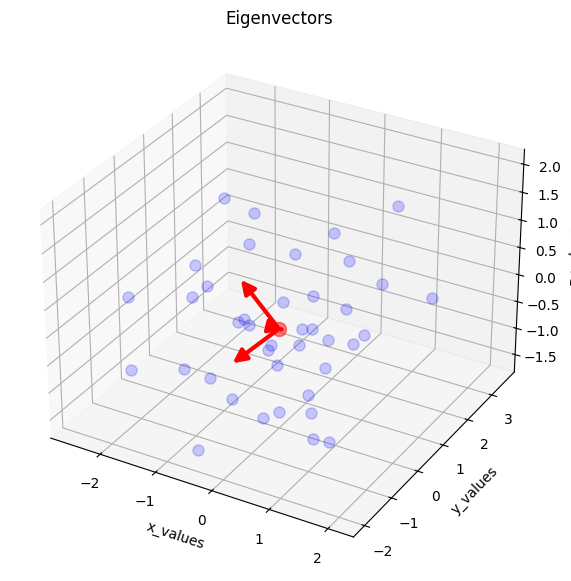

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch
import numpy as np

class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    # Modern matplotlib requires this method instead of draw()
    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        return np.min(zs)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

mean_x = df['feature1'].mean()
mean_y = df['feature2'].mean()
mean_z = df['feature3'].mean()

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([mean_x], [mean_y], [mean_z], 'o', markersize=10, color='red', alpha=0.5)

for v in eigen_vectors.T:
    # Notice the math correction: the end of the arrow is mean + eigenvector
    a = Arrow3D(
        [mean_x, mean_x + v[0]], 
        [mean_y, mean_y + v[1]], 
        [mean_z, mean_z + v[2]], 
        mutation_scale=20, lw=3, arrowstyle="-|>", color="r"
    )
    ax.add_artist(a)

ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')
plt.title('Eigenvectors')

plt.show()

In [23]:
pc=eigen_vectors[0:2]
pc


array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [25]:
# transform
trans_df=np.dot(df.iloc[:,0:3],pc.T)

new_df=pd.DataFrame(trans_df,columns=['PC1','PC2'])
new_df['target']=df['target'].values
new_df.head()

,PC1,PC2,target
0,-0.429384,0.829265,1
1,-1.124520,0.842226,1
2,0.599433,1.795862,1
3,-0.094556,-0.761566,1
4,-0.401542,1.203061,1


In [26]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()
     